In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "data"

def load_test_set(test_name):
    """
    Loads all data files from a given test folder.

    IMS bearing files often have NO extension (e.g., '2003.10.22.12.06.24'),
    so we cannot rely on '.txt'. This function:
      - walks through all subfolders
      - collects all non-archive, non-PDF files
    """

    folder_path = os.path.join(DATA_DIR, test_name)

    data_files = []
    for root, dirs, files in os.walk(folder_path):
        for f in files:
            # Skip obvious non-data files
            if f.lower().endswith((".pdf", ".rar", ".zip")):
                continue
            # Otherwise assume it's a data file
            data_files.append(os.path.join(root, f))

    data_files = sorted(data_files)

    print(f"Loaded {len(data_files)} files from {test_name}")
    data = [np.loadtxt(path) for path in data_files]
    return data, data_files


def plot_example_signal(test_name, index=0):
    """
    Plots one example vibration signal from a test.
    """
    data, files = load_test_set(test_name)

    if len(data) == 0:
        print("No files found – check folder names/structure.")
        return

    if index >= len(data):
        print(f"Index {index} out of range (only {len(data)} files).")
        return

    signal = data[index]

    plt.figure(figsize=(12, 4))
    plt.plot(signal)
    plt.title(f"Example signal from {test_name}: {os.path.basename(files[index])}")
    plt.xlabel("Sample index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()


Loaded 2156 files from 1st_test


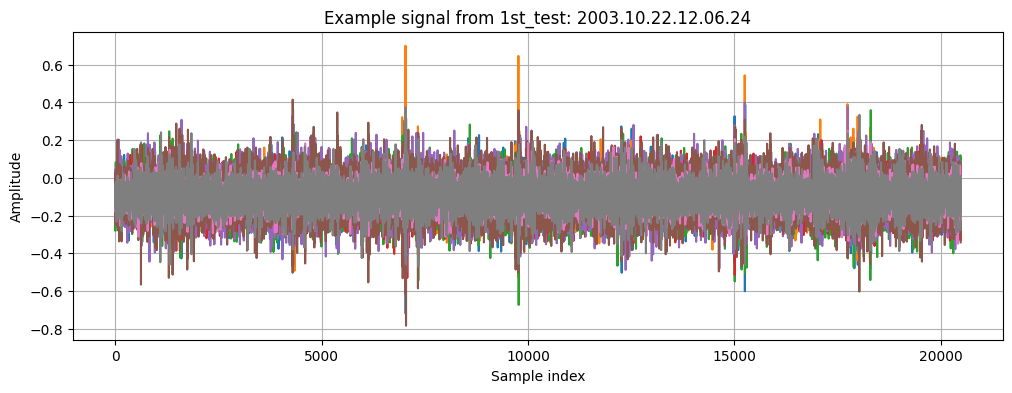

In [19]:
plot_example_signal("1st_test", index=0)


In [2]:
import numpy as np

def compute_features(test_name, channel=0):
    """
    For every file in a test, compute simple features:
      - RMS (root mean square)  -> vibration energy
      - Peak-to-peak amplitude  -> how big the swings are
      - Mean absolute value     -> average vibration level

    channel: which column to use if the data has multiple channels.
             0 is a good default.
    """
    data, files = load_test_set(test_name)

    rms_list = []
    p2p_list = []
    mav_list = []

    for sig in data:
        # If file has multiple columns, pick one channel
        x = sig[:, channel] if sig.ndim == 2 else sig

        rms = np.sqrt(np.mean(x**2))
        p2p = np.max(x) - np.min(x)
        mav = np.mean(np.abs(x))

        rms_list.append(rms)
        p2p_list.append(p2p)
        mav_list.append(mav)

    features = {
        "files": files,
        "rms": np.array(rms_list),
        "p2p": np.array(p2p_list),
        "mav": np.array(mav_list),
    }

    print(f"Computed features for {len(files)} files from {test_name}")
    return features


In [5]:
feats_1 = compute_features("1st_test", channel=0)   # mostly healthy
feats_3 = compute_features("3rd_test", channel=0)   # contains failure


Loaded 2156 files from 1st_test
Computed features for 2156 files from 1st_test
Loaded 6324 files from 3rd_test
Computed features for 6324 files from 3rd_test


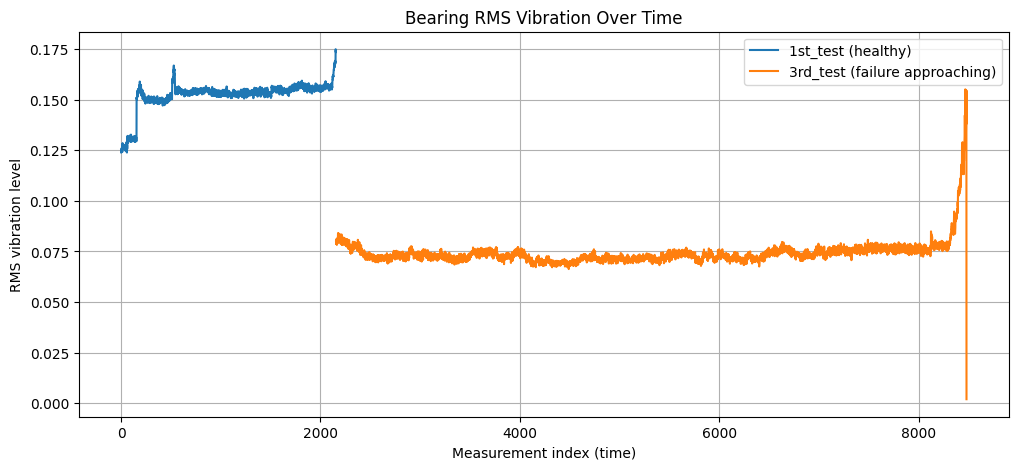

In [10]:
import matplotlib.pyplot as plt
import numpy as np

t1 = np.arange(len(feats_1["rms"]))
t3 = np.arange(len(feats_3["rms"])) + len(feats_1["rms"])

plt.figure(figsize=(12, 5))
plt.plot(t1, feats_1["rms"], label="1st_test (healthy)")
plt.plot(t3, feats_3["rms"], label="3rd_test (failure approaching)")
plt.title("Bearing RMS Vibration Over Time")
plt.xlabel("Measurement index (time)")
plt.ylabel("RMS vibration level")
plt.legend()
plt.grid(True)
plt.show()


In [15]:
from scipy.signal import welch
import numpy as np

def compute_more_features(test_name, channel=0):
    data, files = load_test_set(test_name)

    rms_list = []
    kurtosis_list = []
    crest_factor_list = []
    spectral_energy_list = []

    for sig in data:
        x = sig[:, channel] if sig.ndim == 2 else sig

        # RMS
        rms = np.sqrt(np.mean(x**2))

        # Kurtosis
        kurt = np.mean((x - np.mean(x))**4) / (np.std(x)**4)

        # Crest factor
        crest = np.max(np.abs(x)) / rms

        # Spectral energy
        freqs, psd = welch(x, fs=20000)
        spec_energy = np.sum(psd)

        rms_list.append(rms)
        kurtosis_list.append(kurt)
        crest_factor_list.append(crest)
        spectral_energy_list.append(spec_energy)

    return {
        "rms": np.array(rms_list),
        "kurtosis": np.array(kurtosis_list),       # MUST match this spelling
        "crest_factor": np.array(crest_factor_list),
        "spectral_energy": np.array(spectral_energy_list),
        "files": files
    }


In [18]:
health_score = (
    feats_3["rms"] / np.max(feats_3["rms"]) +
    feats_3["kurtosis"] / np.max(feats_3["kurtosis"]) +
    feats_3["crest_factor"] / np.max(feats_3["crest_factor"]) +
    feats_3["spectral_energy"] / np.max(feats_3["spectral_energy"])
)


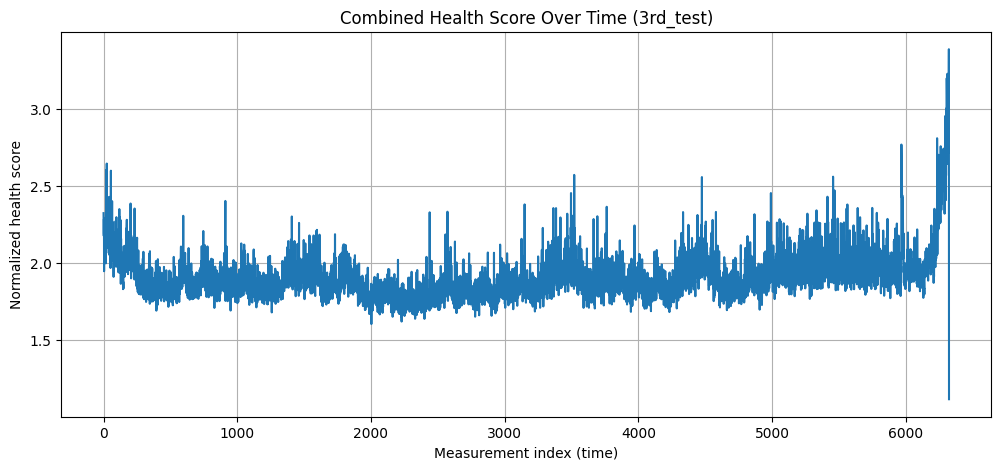

In [19]:
import matplotlib.pyplot as plt
import numpy as np

t3 = np.arange(len(health_score))

plt.figure(figsize=(12, 5))
plt.plot(t3, health_score)
plt.title("Combined Health Score Over Time (3rd_test)")
plt.xlabel("Measurement index (time)")
plt.ylabel("Normalized health score")
plt.grid(True)
plt.show()


In [17]:
feats_1 = compute_more_features("1st_test", channel=0)
feats_3 = compute_more_features("3rd_test", channel=0)


Loaded 2156 files from 1st_test
Loaded 6324 files from 3rd_test


In [20]:
import numpy as np

# Stack features into X matrices
X_healthy = np.column_stack([
    feats_1["rms"],
    feats_1["kurtosis"],
    feats_1["crest_factor"],
    feats_1["spectral_energy"],
])

X_failing = np.column_stack([
    feats_3["rms"],
    feats_3["kurtosis"],
    feats_3["crest_factor"],
    feats_3["spectral_energy"],
])

# Labels: 0 = healthy, 1 = failing
y_healthy = np.zeros(len(X_healthy), dtype=int)
y_failing = np.ones(len(X_failing), dtype=int)

# Combine into one dataset
X = np.vstack([X_healthy, X_failing])
y = np.concatenate([y_healthy, y_failing])

X.shape, y.shape


((8480, 4), (8480,))

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
)

clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)

train_acc, test_acc


(1.0, 1.0)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = clf.predict(X_test)

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))


Confusion matrix:
[[ 647    0]
 [   0 1897]]

Classification report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       647
           1      1.000     1.000     1.000      1897

    accuracy                          1.000      2544
   macro avg      1.000     1.000     1.000      2544
weighted avg      1.000     1.000     1.000      2544



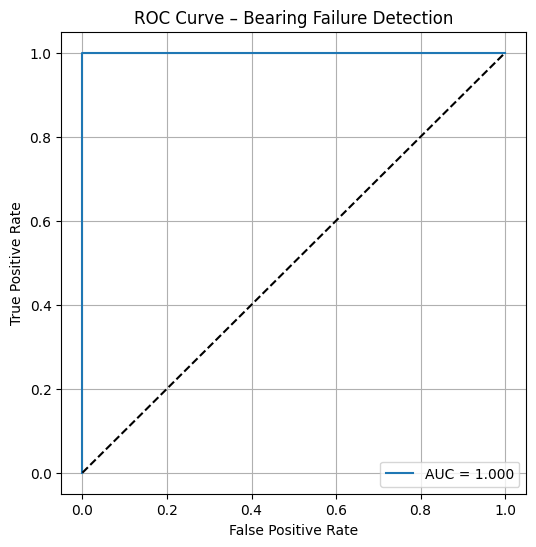

In [23]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:, 1]  # probability of failing

fpr, tpr, thresh = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Bearing Failure Detection")
plt.legend()
plt.grid(True)
plt.show()


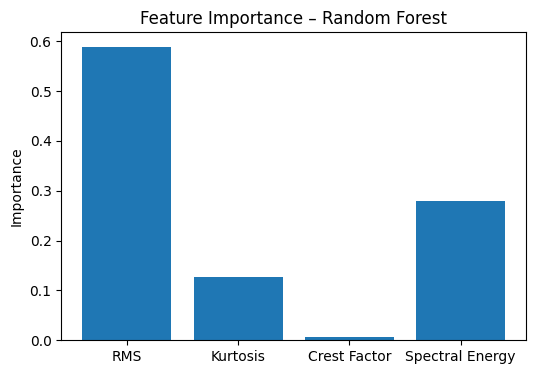

array([0.58827057, 0.12649193, 0.00642339, 0.27881411])

In [24]:
import numpy as np
import matplotlib.pyplot as plt

importances = clf.feature_importances_
feature_names = ["RMS", "Kurtosis", "Crest Factor", "Spectral Energy"]

plt.figure(figsize=(6,4))
plt.bar(feature_names, importances)
plt.title("Feature Importance – Random Forest")
plt.ylabel("Importance")
plt.show()

importances


Loaded 6324 files from 3rd_test


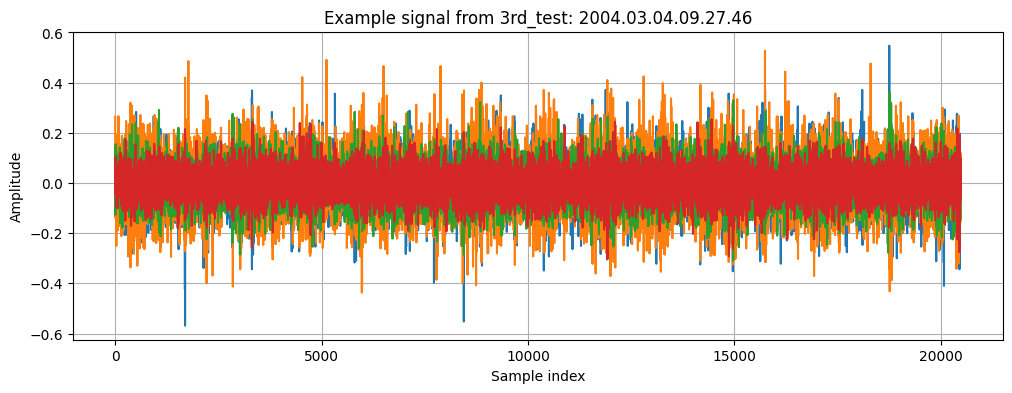

In [20]:
plot_example_signal("3rd_test", index=0)
